In [1]:
from dask.distributed import Client
from dask_jobqueue import SGECluster

cluster = SGECluster(
    memory='8 G',
    cores = 1,
    resource_spec="h_vmem=8G",
    worker_extra_args=["--lifetime", "25m", "--lifetime-stagger", "4m"],
    silence_logs='error'
)

client = Client(cluster)
cluster.adapt(minimum=390, maximum=400)
cluster.wait_for_workers(390)

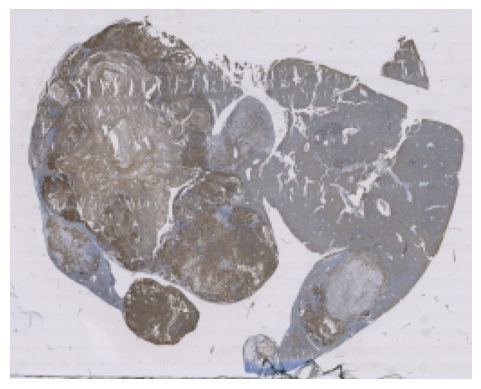

In [4]:
import dask.array as da
from scematk.plot import show_thumb

img_path = '../../trial/Kras_P53_9w_IHC/work/47/20fda65809a779d51a40e21f1c91bd/572_Kras_P53_9w_IHC_00003.zarr'
img = da.from_zarr(img_path)

show_thumb(img)

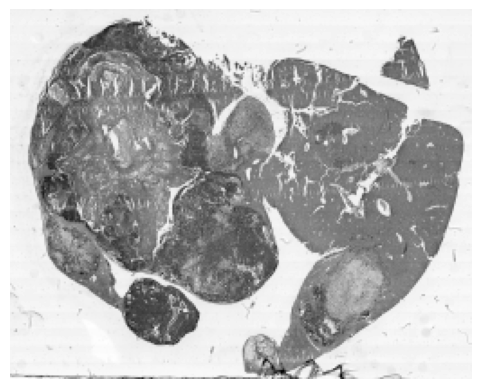

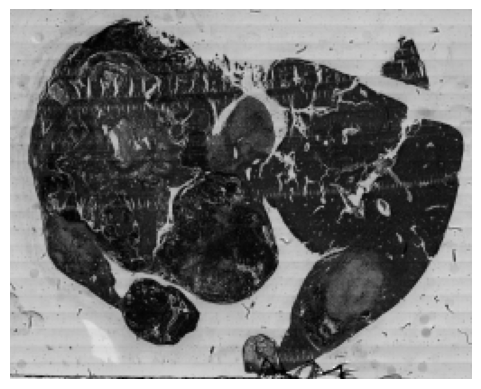

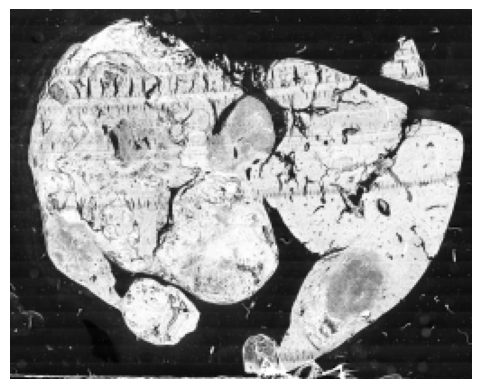

In [5]:
from scematk.process import Processor
from scematk.process.colour import RGBToGrey, GreyToOD
from scematk.process.contrast import GammaContrast2D
from scematk.process.morphology import BinaryOpening, BinaryClosing

processor = Processor()
processor.add_process(RGBToGrey())
show_thumb(processor.process(img))
processor.add_process(GammaContrast2D(gamma=5.0))
show_thumb(processor.process(img))
processor.add_process(GreyToOD())
show_thumb(processor.process(img))

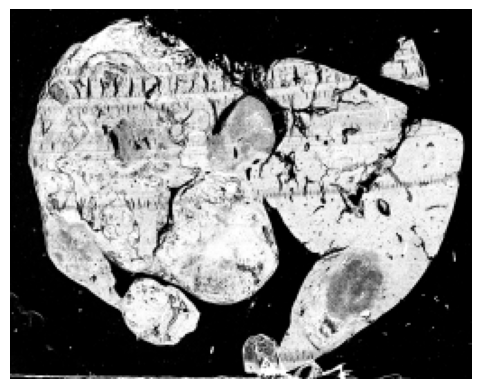

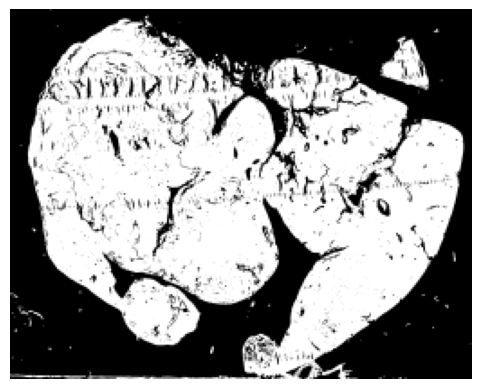

In [7]:
from scematk.segment.tissue import GlobalOtsuTissueSegmenter
import numpy as np

str_ele1 = np.ones((31, 31))
str_ele2 = np.ones((71, 71))

posp = Processor()
posp.add_process(BinaryClosing(structure=str_ele1))
posp.add_process(BinaryOpening(structure=str_ele2))

otsu_thresholder = GlobalOtsuTissueSegmenter(preprocessor=processor, postprocessor=Processor())
tis_mask = otsu_thresholder.fit_and_segment(img)
show_thumb(tis_mask)

otsu_thresholder = GlobalOtsuTissueSegmenter(preprocessor=processor, postprocessor=posp)
tis_mask = otsu_thresholder.fit_and_segment(img)
show_thumb(tis_mask)